# Train, predict, score, and evaluate a Transformer+GBM on PLAsTiCC

Two-stage hybrid classifier:
1. **Stage 1** — Train a lightweight sequence Transformer on raw light-curve sequences.
2. **Stage 2** — Extract Transformer embeddings, concatenate with Boone GP features, train LightGBM on the combined feature matrix.

This notebook uses the `dlip_plasticc` package on top of `avocado`.

In [5]:
# ── Notebook parameters ──────────────────────────────────────────────────────

CONFIG_DEFAULT_PATH = '/home6/s4339150/Courses/dlip_plasticc/configs/default.toml'
CONFIG_LOCAL_PATH   = '/home6/s4339150/Courses/dlip_plasticc/configs/local.toml'

# ── Training dataset ─────────────────────────────────────────────────────────
TRAIN_DATASET_NAME  = 'plasticc_augment'
CLASSIFIER_NAME     = 'my_transformer_gbm'

# ── Sequence branch (Stage 1 Transformer) ────────────────────────────────────
SEQ_LEN                   = 350
TRANSFORMER_EPOCHS        = 30
TRANSFORMER_BATCH_SIZE    = 64
TRANSFORMER_LR            = 1e-4
D_MODEL                   = 128
NHEAD                     = 4
NUM_LAYERS                = 3
DIM_FEEDFORWARD           = 256
DROPOUT                   = 0.2

# ── Fold / training settings ─────────────────────────────────────────────────
NUM_FOLDS             = 5
RANDOM_STATE          = 42
VAL_FOLD              = 0
WEIGHT_DECAY          = 1e-2
LR_SCHEDULER_FACTOR   = 0.5
LR_SCHEDULER_PATIENCE = 2
MIN_LR                = 1e-6
EARLY_STOPPING_PATIENCE = 5

# ── LightGBM overrides (leave empty dict {} to use defaults) ─────────────────
LGBM_PARAMS = {}

# ── Prediction ───────────────────────────────────────────────────────────────
TEST_DATASET_NAME = 'plasticc_test'
TOTAL_CHUNKS      = 500

# Change this list to the chunks you actually want to run.
# For a quick smoke test, use something like [0, 1, 2].
CHUNKS = range(21)

# Location of pre-computed GP feature chunks for the test set.
# These are the same files used by the LightGBM / Transformer notebooks.
FEATURE_BASE    = 'notebook_outputs/gp_features_test'
FEATURE_PATTERN = 'features_test_chunk_{chunk}_plasticc_test.h5'
FEATURE_KEY     = 'raw_features'

# Output location for per-chunk and combined predictions.
OUT_DIR = 'notebook_outputs/transformer_gbm_predictions'

# ── Plot settings ────────────────────────────────────────────────────────────
CONFUSION_NORMALIZE = 'true'   # one of: None, 'true', 'pred', 'all'
FIGSIZE_HISTORY     = (10, 6)
FIGSIZE_CONFUSION   = (10, 8)

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

import avocado

from dlip_plasticc.config import load_config, apply_avocado_settings
from dlip_plasticc.features import PlasticcSequenceFeaturizer
from dlip_plasticc.models import TransformerGBMClassifier
from dlip_plasticc.pipelines.predict import predict_hybrid_partial
from dlip_plasticc.pipelines.score import score_flat, align_truth_and_predictions

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

In [7]:
# Load config and push paths into avocado
cfg = load_config(CONFIG_DEFAULT_PATH, CONFIG_LOCAL_PATH)
apply_avocado_settings(cfg)

print('Using avocado paths:')
print('  data_directory       =', avocado.settings['data_directory'])
print('  features_directory   =', avocado.settings['features_directory'])
print('  predictions_directory=', avocado.settings['predictions_directory'])
print('  classifier_directory =', avocado.settings['classifier_directory'])

Using avocado paths:
  data_directory       = /scratch/s4339150/plasticc/data
  features_directory   = /scratch/s4339150/plasticc/features
  predictions_directory= /scratch/s4339150/plasticc/predictions
  classifier_directory = /scratch/s4339150/plasticc/classifiers


## 1. Train the Transformer + GBM classifier

**Stage 1** trains a sequence Transformer on the raw light curves in the augmented dataset.  
**Stage 2** extracts per-object Transformer embeddings, concatenates them with the 41 Boone GP features,
then trains LightGBM on the combined feature matrix optimising the PLAsTiCC flat-weighted log-loss.

> The dataset must be loaded with `metadata_only=False` so `dataset.objects` is available for the sequence branch.  
> If `dataset.raw_features` is already present, GP features are read from there directly (no recomputation).

In [ ]:
import pandas as pd
import avocado

from dlip_plasticc.features import PlasticcSequenceFeaturizer
from dlip_plasticc.models import TransformerGBMClassifier

seq_featurizer = PlasticcSequenceFeaturizer(seq_len=SEQ_LEN)
gp_featurizer = avocado.plasticc.PlasticcFeaturizer()

classifier = TransformerGBMClassifier(
    name=CLASSIFIER_NAME,
    sequence_featurizer=seq_featurizer,
    gp_featurizer=gp_featurizer,
    transformer_epochs=TRANSFORMER_EPOCHS,
    transformer_batch_size=TRANSFORMER_BATCH_SIZE,
    transformer_lr=TRANSFORMER_LR,
    d_model=D_MODEL,
    nhead=NHEAD,
    num_layers=NUM_LAYERS,
    dim_feedforward=DIM_FEEDFORWARD,
    dropout=DROPOUT,
    lgbm_params=LGBM_PARAMS if LGBM_PARAMS else None,
)

train_dataset = avocado.load(TRAIN_DATASET_NAME, metadata_only=False)

train_dataset.extract_raw_features(seq_featurizer)
seq_raw = train_dataset.raw_features.copy()

gp_raw = pd.read_hdf(
    "/scratch/s4339150/plasticc/features/features_plasticc_augment.h5",
    key="raw_features",
)

classifier.train(
    train_dataset,
    seq_raw=seq_raw,
    gp_raw=gp_raw,
    num_folds=NUM_FOLDS,
    random_state=RANDOM_STATE,
    val_fold=VAL_FOLD,
    weight_decay=WEIGHT_DECAY,
    lr_scheduler_factor=LR_SCHEDULER_FACTOR,
    lr_scheduler_patience=LR_SCHEDULER_PATIENCE,
    min_lr=MIN_LR,
    early_stopping_patience=EARLY_STOPPING_PATIENCE,
    show_progress=True,
)

[Stage 1] Transformer epochs:   0%|          | 0/30 [00:00<?, ?it/s]/home6/s4339150/miniconda/envs/project/lib/python3.10/site-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(
[Stage 1] Transformer epochs:   3%|▎         | 1/30 [00:11<05:24, 11.20s/it]

Epoch 1  train=1.66322  val=1.48623  acc=0.4923  lr=1.00e-04


[Stage 1] Transformer epochs:   7%|▋         | 2/30 [00:21<05:05, 10.93s/it]

Epoch 2  train=1.43314  val=1.37329  acc=0.5383  lr=1.00e-04


[Stage 1] Transformer epochs:  10%|█         | 3/30 [00:32<04:52, 10.83s/it]

...

Epoch 20  train=0.98234  val=1.14337  acc=0.6123  lr=5.00e-05


[Stage 1] Transformer epochs:  70%|███████   | 21/30 [06:21<03:33, 23.74s/it]

Epoch 21  train=0.95938  val=1.10168  acc=0.6276  lr=5.00e-05


[Stage 1] Transformer epochs:  70%|███████   | 21/30 [06:46<02:54, 19.36s/it]


Epoch 22  train=0.95569  val=1.08912  acc=0.6354  lr=5.00e-05
Early stopping at epoch 22. Best val=1.06322
[Stage 1] Best transformer val loss: 1.06322
[Stage 2] Extracting transformer embeddings…
[Stage 2] Training LightGBM on 210 features (128 transformer + 82 GP)…
Training until validation scores don't improve for 50 rounds
[50]	valid_0's multi_logloss: 1.66338
[100]	valid_0's multi_logloss: 1.64096
[150]	valid_0's multi_logloss: 1.63274
[200]	valid_0's multi_logloss: 1.62882
[250]	valid_0's multi_logloss: 1.62656
[300]	valid_0's multi_logloss: 1.62539
[350]	valid_0's multi_logloss: 1.62447
[400]	valid_0's multi_logloss: 1.62376
[450]	valid_0's multi_logloss: 1.62341
[500]	valid_0's multi_logloss: 1.62306
[550]	valid_0's multi_logloss: 1.62287
[600]	valid_0's multi_logloss: 1.62248
[650]	valid_0's multi_logloss: 1.62231
[700]	valid_0's multi_logloss: 1.62211
[750]	valid_0's multi_logloss: 1.62192
[800]	valid_0's multi_logloss: 1.62195
Early stopping, best iteration is:
[775]	valid_0

In [5]:
# Save the trained classifier
classifier.write(overwrite=True)
print('Classifier written to:', classifier.path)

Classifier written to: /scratch/s4339150/plasticc/classifiers/classifier_my_transformer_gbm.pkl


## 2. Plot Stage-1 Transformer training history

In [4]:
history = classifier.history.copy()
history.tail()

NameError: name 'classifier' is not defined

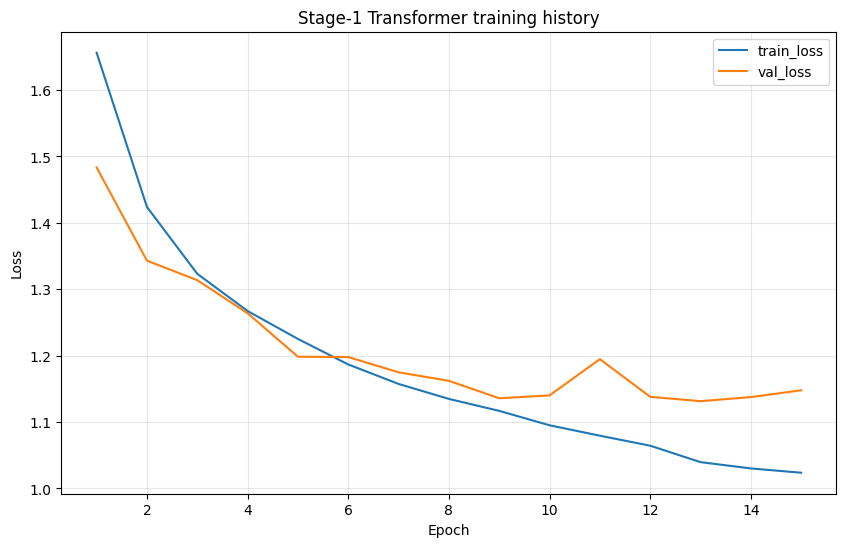

In [7]:
fig, ax = plt.subplots(figsize=FIGSIZE_HISTORY)
ax.plot(history['epoch'], history['train_loss'], label='train_loss')
ax.plot(history['epoch'], history['val_loss'],   label='val_loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Stage-1 Transformer training history')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

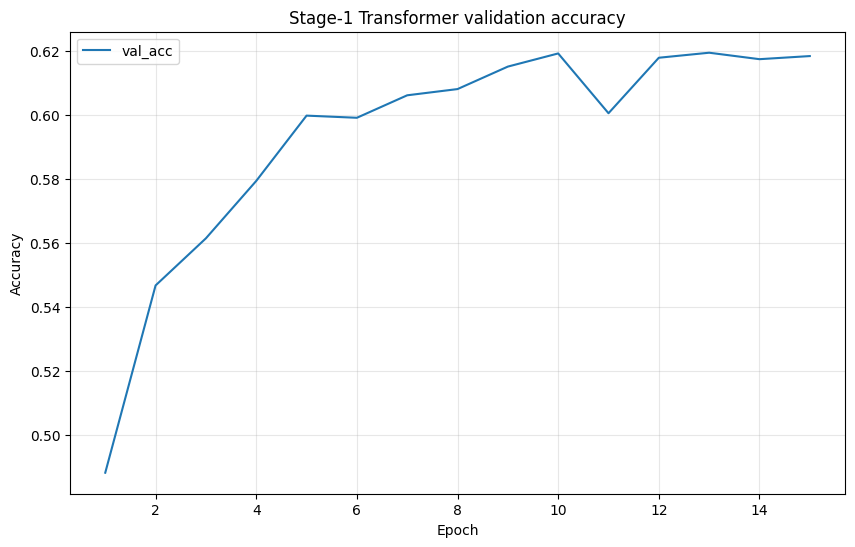

In [8]:
fig, ax = plt.subplots(figsize=FIGSIZE_HISTORY)
ax.plot(history['epoch'], history['val_acc'], label='val_acc')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.set_title('Stage-1 Transformer validation accuracy')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

## 3. Predict on test chunks

`predict_hybrid_partial` loads each test chunk with **`metadata_only=False`** (so the sequence branch
gets real observations) and injects precomputed GP features from disk into `dataset.raw_features`
(so the GP branch does not need to recompute them).

In [9]:
Path(OUT_DIR).mkdir(parents=True, exist_ok=True)

combined_predictions, processed_chunks = predict_hybrid_partial(
    classifier=classifier,
    dataset_name=TEST_DATASET_NAME,
    total_chunks=TOTAL_CHUNKS,
    chunks=CHUNKS,
    feature_base=FEATURE_BASE,
    feature_pattern=FEATURE_PATTERN,
    feature_key=FEATURE_KEY,
    out_dir=OUT_DIR,
    show_progress=True,
)

print('Processed chunks:', processed_chunks)
print('Combined prediction shape:', combined_predictions.shape)
combined_predictions.head()

Chunks:   0%|          | 0/21 [00:04<?, ?it/s]


FileNotFoundError: Missing feature file for chunk 0: notebook_outputs/gp_features_test/features_test_chunk_0_plasticc_test.h5

## 4. Score predictions with avocado flat-weighted log-loss

This scores only on the overlapping labeled objects available in the metadata.

In [ ]:
flat_score, n_scored = score_flat(TEST_DATASET_NAME, combined_predictions)
print(f'Flat-weighted log-loss: {flat_score:.5f}')
print(f'Objects scored:         {n_scored:,}')

## 5. Confusion matrix

In [ ]:
y_true, pred_aligned = align_truth_and_predictions(
    TEST_DATASET_NAME,
    combined_predictions,
    known_classes_only=True,
    normalize=True,
)

y_pred  = pred_aligned.idxmax(axis=1)
labels  = sorted(np.unique(np.concatenate([y_true.values, y_pred.values])))

cm = confusion_matrix(y_true, y_pred, labels=labels, normalize=CONFUSION_NORMALIZE)

fig, ax = plt.subplots(figsize=FIGSIZE_CONFUSION)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels,
)

disp.plot(
    ax=ax,
    xticks_rotation=45,
    colorbar=True,
    cmap=plt.cm.Blues,
    values_format='.2f',
)

ax.set_title('Confusion matrix on scored predictions')
plt.tight_layout()
plt.show()

In [ ]:
print(classification_report(y_true, y_pred, digits=4))

## 6. Optional: Save combined predictions to CSV

Useful if you want a quick export without opening the HDF file.

In [ ]:
csv_path = Path(OUT_DIR) / 'predictions_combined.csv'
combined_predictions.to_csv(csv_path)
print('Wrote:', csv_path)